In [67]:
from random import sample

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as st
import scipy.optimize as opt
import seaborn as sns
import math as mt
from IPython.display import display, Math
from numpy.ma.extras import hstack
from skimage.io import imread, imsave



Генерация выборки n = 50

In [68]:
n = 50
ksi = np.random.uniform(-1, 1, (n, 5))
etha = np.random.normal(2 + 3 * ksi[:, 0] - 2 * ksi[:, 1] + ksi[:, 2] + ksi[:, 3] - ksi[:, 4], 1.5)
X = np.hstack((ksi, etha.reshape(-1, 1)))
print(X)

[[ 8.05826463e-01  4.27768445e-01  2.47528292e-01 -8.75718250e-01
   7.58369548e-02  3.38693384e+00]
 [-6.14846579e-01 -1.23295221e-01  9.82344374e-01  3.41031769e-01
   6.51367310e-01 -6.64178211e-01]
 [-5.44302571e-01 -9.85553415e-01  6.36049189e-01 -4.39821446e-01
   7.45253251e-01  1.67997112e+00]
 [ 8.21560107e-01 -7.76825598e-01  2.79818998e-01 -7.10484571e-01
  -8.10892937e-01  6.03314330e+00]
 [-7.26732720e-01  7.63595194e-01  3.48218118e-01 -2.98774019e-01
  -7.89227887e-01 -3.56432740e+00]
 [-7.66897060e-01  9.80802125e-01 -3.29733824e-01 -9.36331440e-01
   1.60261552e-01 -4.06098543e+00]
 [-3.78705187e-01  3.23602769e-01  4.20153906e-01  4.06960016e-01
  -8.04454458e-01 -3.00905600e-01]
 [ 2.70178117e-01 -5.54332464e-01  5.34782050e-02 -6.42219512e-01
  -4.31480428e-01  2.10673214e+00]
 [ 5.49523920e-01 -7.37979975e-01  5.02975293e-01  4.05535020e-02
  -1.02975359e-01  4.66381542e+00]
 [-6.85910975e-01 -1.99315504e-01  5.76392286e-01 -1.38535321e-01
  -1.03619991e-01  2.3143

Проверка $\xi_k$ на мультиколлинеарность

In [69]:
corr_m = np.corrcoef(ksi, rowvar=False)
print(corr_m)
r_max = np.max(np.abs(corr_m - np.eye(corr_m.shape[0])))
print(r_max)
if r_max > 0.7:
    print("Есть мультиколлинеарность")
else:
    print("Мультиколлинеарность отсутствует")

[[ 1.         -0.19089423 -0.17479696  0.13008225 -0.21589285]
 [-0.19089423  1.          0.22148796 -0.06945715 -0.21115631]
 [-0.17479696  0.22148796  1.         -0.0902853  -0.04385375]
 [ 0.13008225 -0.06945715 -0.0902853   1.          0.09256396]
 [-0.21589285 -0.21115631 -0.04385375  0.09256396  1.        ]]
0.22148795742057525
Мультиколлинеарность отсутствует


Определяем уравнение линейной регрессии

In [70]:
psi = np.hstack((np.ones((n, 1)), X[:, 0:5]))
F = psi.T @ psi
Y = X[:, 5]
betta = np.linalg.inv(F) @ psi.T @ Y
expr = f"{betta[0]:.3f}"
for i in range(1, len(betta)):
    sign = "+" if betta[i] >= 0 else "-"
    expr += f" {sign} {abs(betta[i]):.3f} \\xi_{{{i}}}"
display(Math(f"\\eta = {expr}"))

<IPython.core.display.Math object>

Проверка значимости коэффицентов регрессии

In [87]:
n, p = psi.shape
e = Y - psi @ betta
F_inv = np.linalg.inv(F)
RSS = e.T @ e
sigma2 = RSS / (n - p)
cov_beta = sigma2 * np.linalg.inv(F.T)
std_err = np.sqrt(np.diag(cov_beta))
t_stats = betta / std_err
p_values = 2 * (1 - st.t.cdf(np.abs(t_stats), df=n-p))
alpha = .05
expr = ""
for i in range(len(p_values)):
    status = "значима" if p_values[i] < alpha else "не значима"
    display(Math(
        fr"\text{{p-value для }} \xi_{{{i}}} = {p_values[i]:.4f} \;\Rightarrow\; "
        fr"\text{{{status}}} \; (\alpha = {alpha})"
    ))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Коэффицент детерминации и его значимость

In [95]:
TSS = np.sum((Y - np.mean(Y)) ** 2)
R2 = (TSS - RSS) / TSS
print(f"R2 = {R2:.4f}")
delta = ((TSS - RSS) / (p - 1)) / (RSS / (n - p))
p_value = 1 - st.t.cdf(delta, p - 1, n - p)
print(p_value)

R2 = 0.7839
0.9999657749231636


Значение в точке 0 и 95% доверительный интервал

In [97]:
psi0 = np.array([1, 0, 0, 0, 0, 0])

y0_hat = psi0 @ betta
se_mean = np.sqrt(sigma2 * (psi0.T @ F_inv @ psi0))
alpha = 0.05
t_crit = st.t.ppf(1 - alpha/2, df=n - p)
i_left = y0_hat - t_crit * se_mean
i_right = y0_hat + t_crit * se_mean
display(Math(
    fr"\hat{{\eta}}(0,0,0,0,0) = {y0_hat:.4f}, \quad "
    fr"I_{{95\%}} = \left({i_left:.4f};\; {i_right:.4f}\right)"
))

<IPython.core.display.Math object>

Проверка предположения о независимости ошибок измерения

In [102]:
I = 0
print(len(e))
for i in range(len(e)):
    for j in range(i + 1, len(e)):
        I += 1 if e[i] > e[j] else 0

delta = (I - (n - 1) * n / 4) / np.sqrt(n ** 3 / 36)
p_value = 2 * (1 - st.norm.cdf(abs(delta)))
print(p_value)
if p_value > alpha:
    print("Нет оснований отвергать гипотезу о независимости ошибок")
else:
    print("Гипотеза о независимости ошибок отвергается")

50
0.581261299930204
Нет оснований отвергать гипотезу о независимости ошибок


Проверка гипотезы о нормальности распределения ошибок

In [110]:
sigma = np.std(e, ddof=1)
e_sorted = np.sort(e)
F_emp = np.arange(1, n+1) / n
Phi = st.norm.cdf(e_sorted, loc=0, scale=sigma)
D = np.max(np.abs(F_emp - Phi))
delta = np.sqrt(n) * D

B = 10000
deltas_star = []
for _ in range(B):
    # генерируем нормальную выборку
    e_star = np.random.normal(0, sigma, n)
    e_star_sorted = np.sort(e_star)
    F_emp_star = np.arange(1, n+1) / n
    Phi_star = st.norm.cdf(e_star_sorted, loc=0, scale=sigma)
    D_star = np.max(np.abs(F_emp_star - Phi_star))
    deltas_star.append(np.sqrt(n) * D_star)

deltas_star = np.array(deltas_star)
p_value = np.mean(deltas_star >= delta)
print("delta =", delta)
print("p-value =", p_value)
if p_value > alpha:
    print("Нет оснований отвергать нормальность")
else:
    print("Нормальность отвергается")

delta = 0.35183943871172957
p-value = 0.9909
Нет оснований отвергать нормальность


Проверка регрессии на выбросы

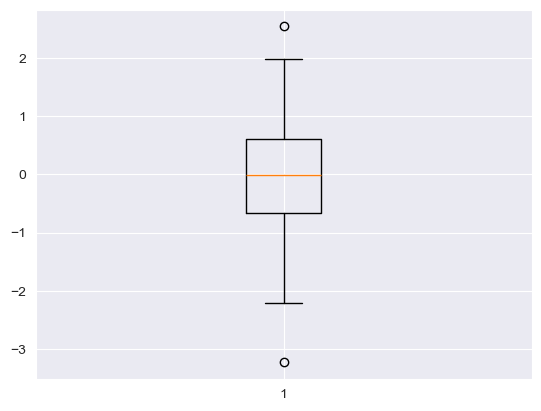

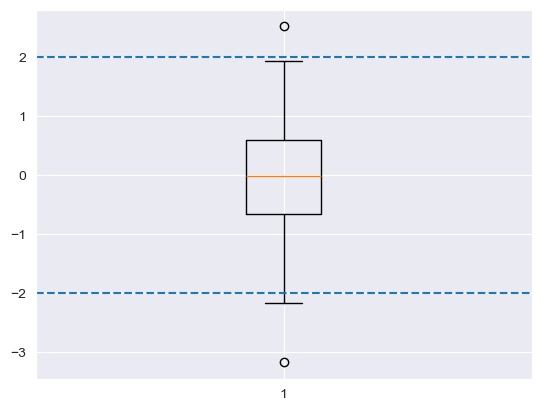

In [112]:
plt.boxplot(e)
plt.show()

H = psi @ F_inv @ psi.T
h = np.diag(H)
std_res = e / np.sqrt(sigma2 * (1 - h))
plt.boxplot(std_res)
plt.axhline(2, linestyle="--")
plt.axhline(-2, linestyle="--")
plt.show()

Кросс проверка регрессии

In [124]:
def CVSS(psi_train, Y_train, psi_test, Y_test):
    F_train = psi_train.T @ psi_train
    F_train_inv = np.linalg.inv(F_train)
    betta12_hat = F_train_inv @ psi_train.T @ Y_train

    Y_hat_test = psi_test @ betta12_hat
    CVSSij = np.sum((Y_test - Y_hat_test) ** 2)
    return CVSSij

psi_train = psi[:34]
Y_train = Y[:34]
psi_test = psi[34:]
Y_test = Y[34:]
CVSS12 = CVSS(psi_train, Y_train, psi_test, Y_test)
psi_train = psi[17:]
Y_train = Y[17:]
psi_test = psi[17:]
Y_test = Y[17:]
CVSS13 = CVSS(psi_train, Y_train, psi_test, Y_test)
print(psi_train)
psi_train = np.vstack((psi[:17], psi[33:]))
Y_train =
print(psi_train)




[[ 1.          0.17079152 -0.91937947 -0.59133776  0.8703802  -0.94689214]
 [ 1.          0.44592047  0.24200379  0.92574114  0.5697563   0.38474073]
 [ 1.         -0.85239834  0.53438791  0.54338408 -0.68449388  0.95047003]
 [ 1.         -0.28951131 -0.98046815 -0.71453146  0.41189103  0.92437625]
 [ 1.         -0.39746069  0.03815261  0.01440683 -0.2490139   0.652885  ]
 [ 1.         -0.31491753 -0.40537304 -0.68789732  0.39754103 -0.05899203]
 [ 1.          0.16449705  0.07193384  0.70882769  0.60022865  0.51717072]
 [ 1.         -0.79337401  0.86856385  0.99965721 -0.75467879 -0.58611948]
 [ 1.          0.28833638  0.93275915 -0.66580165  0.88473274 -0.16742813]
 [ 1.         -0.72714871  0.8248639   0.26733612 -0.68248815  0.80915344]
 [ 1.         -0.22869332 -0.7671887  -0.11778974 -0.89596523  0.37816628]
 [ 1.          0.36775236 -0.10316657  0.65702234 -0.30046428 -0.18189644]
 [ 1.         -0.32308827 -0.53008684  0.02045589 -0.64503515 -0.36627492]
 [ 1.          0.78515661